In [ ]:
from datasets import load_dataset
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer
import random
from collections import Counter

# Load the IMDB dataset from HuggingFace
dataset = load_dataset("imdb")

# Load tokenizer for DeBERTa
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Custom PyTorch Dataset class to tokenize and handle data
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Tokenize the input text
        encodings = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": encodings["input_ids"].squeeze(0),
            "attention_mask": encodings["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.float)
        }


# Separate texts and labels
train_data = dataset["train"]
test_data = dataset["test"]

# Init number of sample
nb_train_sample = 2000
nb_test_sample = 1000

# Filter by label
# Subsample the dataset (first 2000 for train, 1000 for test)
train_pos = [ex for ex in train_data if ex["label"] == 1][:int(nb_train_sample/2)] #list of dictionary, each dict contains text and label
train_neg = [ex for ex in train_data if ex["label"] == 0][:int(nb_train_sample/2)]
test_pos = [ex for ex in test_data if ex["label"] == 1][:int(nb_test_sample/2)]
test_neg = [ex for ex in test_data if ex["label"] == 0][:int(nb_test_sample/2)]

# Combine and shuffle
train_subset = train_pos + train_neg #list of dictionary, each dict contains text and label
test_subset = test_pos + test_neg

random.shuffle(train_subset)
random.shuffle(test_subset)

# Extract texts and labels
train_texts = [ex["text"] for ex in train_subset]
train_labels = [ex["label"] for ex in train_subset]
test_texts = [ex["text"] for ex in test_subset]
test_labels = [ex["label"] for ex in test_subset]

from sklearn.model_selection import train_test_split
# Stratified split: 80% train, 20% val
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.2, stratify=train_labels, random_state=42
)

# Convert dataset into PyTorch DataLoaders
train_dataset = IMDBDataset(train_texts, train_labels, tokenizer)
val_dataset = IMDBDataset(val_texts, val_labels, tokenizer)
test_dataset = IMDBDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [19]:
print(Counter(train_dataset.labels))
print(Counter(val_dataset.labels))
print(Counter(test_dataset.labels))

Counter({0: 80, 1: 80})
Counter({0: 20, 1: 20})
Counter({0: 50, 1: 50})


In [20]:
import torch
import torch.nn as nn
from transformers import AutoModel

class MoE(nn.Module):
    def __init__(self, expert_model_names, hidden_size=768, num_classes=2):
        """
        expert_model_names: list of HuggingFace model names (e.g., ['distilbert-base-uncased', ...])
        hidden_size: size of the hidden layer (768 for BERT/RoBERTa/DeBERTa small models)
        num_classes: output classes (2 for binary classification like sentiment)
        """
        super().__init__()

        # Load and store each expert model
        self.experts = nn.ModuleList([
            AutoModel.from_pretrained(model_name) for model_name in expert_model_names
        ])

        # Gating network: decides how much weight to assign to each expert
        self.gate = nn.Sequential(
            nn.Linear(hidden_size, len(expert_model_names)),
            nn.Softmax(dim=1)  # Ensures weights across experts sum to 1
        )

        # Final classification layer using the weighted expert representation
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, input_ids, attention_mask, return_gate=False):
        expert_outputs = []

        # Pass input through each expert and get the [CLS] token output
        for expert in self.experts:
            cls_output = expert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
            expert_outputs.append(cls_output.unsqueeze(1))  # Shape: (B, 1, H)

        # Stack all expert outputs: Shape becomes (B, num_experts, H)
        expert_outputs = torch.cat(expert_outputs, dim=1)

        # Use the first expert’s output as input to the gating network (or use average if preferred)
        gate_input = expert_outputs[:, 0, :]  # Shape: (B, H)

        # Compute gate weights: Shape (B, num_experts)
        gate_weights = self.gate(gate_input)

        # Compute weighted sum of expert outputs: Shape (B, H)
        moe_output = torch.sum(expert_outputs * gate_weights.unsqueeze(-1), dim=1)

        # Classification logits: Shape (B, num_classes)
        logits = self.classifier(moe_output)

        if return_gate:
            return logits, gate_weights  # Useful for visualization
        return logits


In [21]:
# import torch.nn.functional as F

# # Training loop
# def train(model, dataloader, optimizer, device):
#     model.train()
#     total_loss = 0
#     for batch in dataloader:
#         input_ids = batch["input_ids"].to(device)
#         attention_mask = batch["attention_mask"].to(device)
#         labels = batch["label"].to(device)

#         optimizer.zero_grad()

#         # Get model predictions
#         logits = model(input_ids=input_ids, attention_mask=attention_mask).squeeze()

#         # Compute binary classification loss
#         loss = F.binary_cross_entropy_with_logits(logits, labels)

#         # Backpropagation
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     return total_loss / len(dataloader)

# def evaluate(model, dataloader, device):
#     model.eval()
#     correct = 0
#     total = 0
#     all_gates = []

#     with torch.no_grad():
#         for batch in dataloader:
#             input_ids = batch["input_ids"].to(device)
#             attention_mask = batch["attention_mask"].to(device)
#             labels = batch["label"].to(device)

#             # Get predictions and gate weights
#             logits, gate_weights = model(input_ids=input_ids, attention_mask=attention_mask, return_gate=True)

#             # Convert logits to binary predictions
#             preds = torch.round(torch.sigmoid(logits.squeeze()))

#             correct += (preds == labels).sum().item()
#             total += labels.size(0)

#             # Store gate weights for plotting
#             all_gates.extend(gate_weights.cpu().tolist())

#     print("Sample gate weights from evaluation:", all_gates[:5])
#     return correct / total, all_gates

In [30]:
import torch.nn.functional as F

def train(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(input_ids=input_ids, attention_mask=attention_mask).squeeze()
        loss = F.binary_cross_entropy_with_logits(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.sigmoid(logits)
        predicted = (preds > 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total

    return avg_loss, accuracy

def evaluate(model, dataloader, device, return_loss=False, return_preds=False):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_gate_weights = []
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            logits, gate_weights = model(input_ids=input_ids, attention_mask=attention_mask, return_gate=True)
            logits = logits.squeeze()
            preds = torch.sigmoid(logits)
            predicted = (preds > 0.5).float()

            loss = F.binary_cross_entropy_with_logits(logits, labels)
            total_loss += loss.item()

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_gate_weights.extend(gate_weights.cpu().numpy())

    acc = correct / total
    avg_loss = total_loss / len(dataloader)

    results = [acc, all_gate_weights]
    if return_loss:
        results.append(avg_loss)
    if return_preds:
        results.extend([all_preds, all_labels])
    return tuple(results)

import matplotlib.pyplot as plt

def plot_gate_distribution(gate_weights_list, expert_names):
    """
    Plots the average gate weight assigned to each expert.

    Parameters:
    - gate_weights_list: list of gate weights per batch/sample, shape (N, num_experts)
                         Each element should be a tensor or list of length num_experts.
    - expert_names: list of names corresponding to each expert.
    """
    # Convert list of tensors/lists to NumPy array
    gate_array = np.array(gate_weights_list)  # Shape: (num_samples, num_experts)

    # Check shape
    if gate_array.shape[1] != len(expert_names):
        raise ValueError(f"Expected {len(expert_names)} experts, but got {gate_array.shape[1]} gate weights per sample.")

    # Average weights across all samples
    avg_weights = np.mean(gate_array, axis=0)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.bar(expert_names, avg_weights, color='skyblue')
    plt.title("Average Gate Weights per Expert")
    plt.ylabel("Average Weight")
    plt.xlabel("Expert")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MoE with small/light models
expert_model_names = [
    "distilbert-base-uncased",
    "distilroberta-base",
    "microsoft/deberta-v3-small"
]

model = MoE(expert_model_names,
            hidden_size=768,
            num_classes=1).to(device)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [41]:
num_epochs = 64
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, optimizer, device)
    val_acc, val_gate_weights, val_loss = evaluate(model, val_loader, device, return_loss=True)
    
    # train_eval = evaluate(model, train_loader, device, return_loss=False)
    # train_acc = train_eval[0]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1 | Train Loss: 0.1812 | Train Acc: 0.9750 | Val Acc: 0.9000
Epoch 2 | Train Loss: 0.0883 | Train Acc: 1.0000 | Val Acc: 0.8250
Epoch 3 | Train Loss: 0.0456 | Train Acc: 1.0000 | Val Acc: 0.9000
Epoch 4 | Train Loss: 0.0218 | Train Acc: 1.0000 | Val Acc: 0.8750
Epoch 5 | Train Loss: 0.0123 | Train Acc: 1.0000 | Val Acc: 0.8250
Epoch 6 | Train Loss: 0.0090 | Train Acc: 1.0000 | Val Acc: 0.8000
Epoch 7 | Train Loss: 0.0061 | Train Acc: 1.0000 | Val Acc: 0.8500
Epoch 8 | Train Loss: 0.0043 | Train Acc: 1.0000 | Val Acc: 0.8750
Epoch 9 | Train Loss: 0.0033 | Train Acc: 1.0000 | Val Acc: 0.8750
Epoch 10 | Train Loss: 0.0028 | Train Acc: 1.0000 | Val Acc: 0.8750
Epoch 11 | Train Loss: 0.0023 | Train Acc: 1.0000 | Val Acc: 0.8750
Epoch 12 | Train Loss: 0.0020 | Train Acc: 1.0000 | Val Acc: 0.8750
Epoch 13 | Train Loss: 0.0017 | Train Acc: 1.0000 | Val Acc: 0.8750
Epoch 14 | Train Loss: 0.0015 | Train Acc: 1.0000 | Val Acc: 0.8750
Epoch 15 | Train Loss: 0.0014 | Train Acc: 1.0000 | Val A

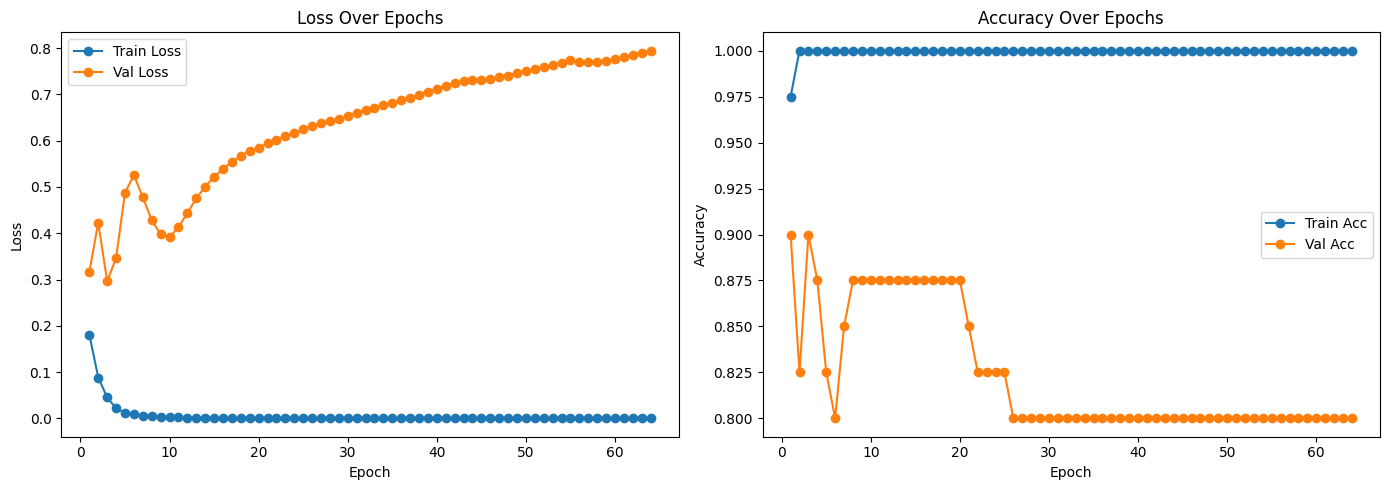

In [42]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker = 'o')
plt.plot(epochs, val_losses, label='Val Loss', marker = 'o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Acc', marker = 'o')
plt.plot(epochs, val_accuracies, label='Val Acc', marker = 'o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
test_acc, gate_weights, test_loss, test_preds, test_labels = evaluate(
    model, test_loader, device, return_loss=True, return_preds=True
)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.7800


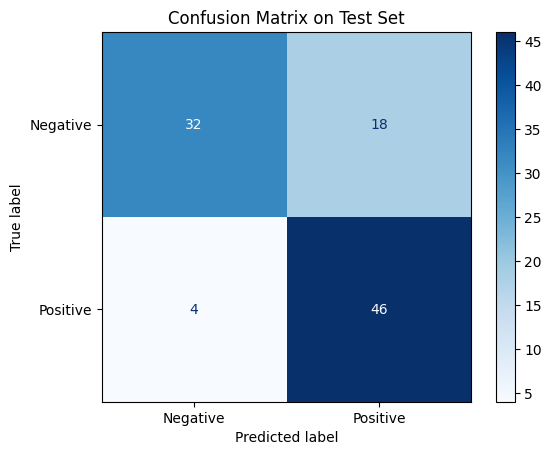

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix on Test Set")
plt.show()

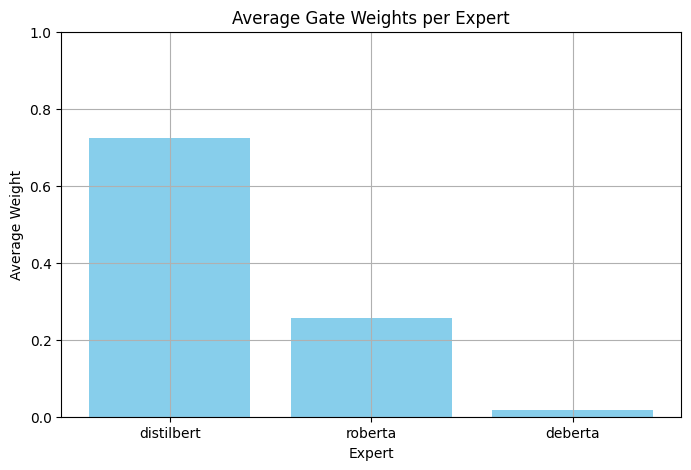

In [45]:
plot_gate_distribution(
    gate_weights_list=gate_weights,  # List of gate weights collected during evaluation
    expert_names=["distilbert", "roberta", "deberta"]
)

In [46]:
# # import numpy as np

# nb_epochs = 64
# for epoch in range(nb_epochs):
#     train_loss = train(model, train_loader, optimizer, device)
#     accuracy, gate_weights = evaluate(model, test_loader, device)
#     print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Test Accuracy = {accuracy:.4f}")

# #print("MoE's accuracy:", accuracy)

# # weight_experts = [[], [], []]
# # for ele in gate_weights:
# #     weight_experts[0].append(ele[0])
# #     weight_experts[1].append(ele[1])
# #     weight_experts[2].append(ele[2])

# # avg_gate_weights = []
# # for expert in weight_experts:
# #     avg_gate_weights.append(np.mean(expert))

# # import matplotlib.pyplot as plt

# # # Suppose gate_weights is a tensor of shape (B, num_experts)
# # #avg_gate_weights = gate_weights.mean(dim=0).cpu().numpy()
# # plt.bar(range(len(expert_model_names)), avg_gate_weights, tick_label=expert_model_names)
# # plt.title("Average Gate Weights Across Test Set")
# # plt.ylabel("Weight")
# # plt.show()


# import matplotlib.pyplot as plt
# import numpy as np

# def plot_gate_distribution(gate_weights_list, expert_names):
#     """
#     Plots the average gate weight assigned to each expert.

#     Parameters:
#     - gate_weights_list: list of gate weights per batch/sample, shape (N, num_experts)
#                          Each element should be a tensor or list of length num_experts.
#     - expert_names: list of names corresponding to each expert.
#     """
#     # Convert list of tensors/lists to NumPy array
#     gate_array = np.array(gate_weights_list)  # Shape: (num_samples, num_experts)

#     # Check shape
#     if gate_array.shape[1] != len(expert_names):
#         raise ValueError(f"Expected {len(expert_names)} experts, but got {gate_array.shape[1]} gate weights per sample.")

#     # Average weights across all samples
#     avg_weights = np.mean(gate_array, axis=0)

#     # Plot
#     plt.figure(figsize=(8, 5))
#     plt.bar(expert_names, avg_weights, color='skyblue')
#     plt.title("Average Gate Weights per Expert")
#     plt.ylabel("Average Weight")
#     plt.xlabel("Expert")
#     plt.ylim(0, 1)
#     plt.grid(True)
#     plt.show()


# plot_gate_distribution(
#     gate_weights_list=gate_weights,  # List of gate weights collected during evaluation
#     expert_names=["distilbert", "roberta", "deberta"]
# )
